[ Info: Saved animation to /home/fdx/Programming/GitHub/notebook-ideas/julia/vector_sum.gif


Plots.AnimatedGif("/home/fdx/Programming/GitHub/notebook-ideas/julia/vector_sum.gif")
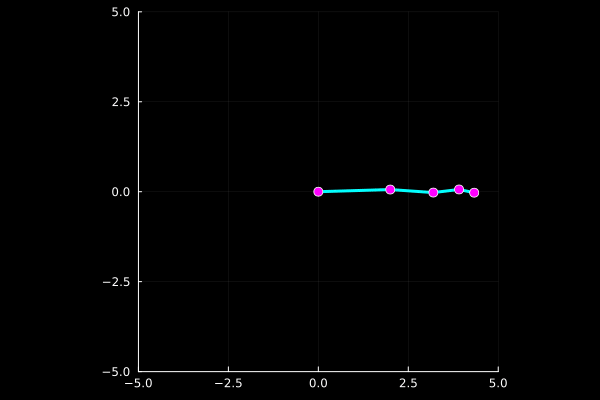

In [1]:
using Plots

# 1. Configuration (All angles in radians, speeds per frame)
lengths = [2.0, 1.2, 0.72, 0.43]  # Vector lengths (decaying)
speeds  = [0.03, -0.07, 0.12, -0.21] # Rotation speeds
angles  = [0.0, 0.0, 0.0, 0.0]     # Initial angles

trail_x, trail_y = Float64[], Float64[]

# 2. Setup the animation loop
anim = @animate for frame in 1:200
    # Update angles
    global angles += speeds

    # Calculate vector joints step-by-step
    x, y = zeros(5), zeros(5)
    for i in 1:4
        x[i+1] = x[i] + lengths[i] * cos(angles[i])
        y[i+1] = y[i] + lengths[i] * sin(angles[i])
    end

    # Store the tip of the last vector for the path trail
    push!(trail_x, x[end])
    push!(trail_y, y[end])

    # 3. Static frame rendering (No heavy reactive elements)
    # Background trail
    plot(trail_x, trail_y, color=:yellow, lw=2, legend=false,
         bg=:black, fg=:white, xlims=(-5,5), ylims=(-5,5), aspect_ratio=:equal)
    
    # Vector bones
    plot!(x, y, color=:cyan, lw=3)
    
    # Vector joints
    scatter!(x, y, color=:magenta, ms=5)
end

# 4. Compile to GIF and display inline in Jupyter
gif(anim, "vector_sum.gif", fps=30)
